In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='latin1')

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
for col in df.columns:
    print("-", col)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (9994, 21)

Column Names:
- Row ID
- Order ID
- Order Date
- Ship Date
- Ship Mode
- Customer ID
- Customer Name
- Segment
- Country
- City
- State
- Postal Code
- Region
- Product ID
- Category
- Sub-Category
- Product Name
- Sales
- Quantity
- Discount
- Profit

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [5]:
print("Total Sales: ${:,.2f}".format(df['Sales'].sum()))
print("Total Profit: ${:,.2f}".format(df['Profit'].sum()))
print("Total Orders:", df['Order ID'].nunique())
print("Total Customers:", df['Customer ID'].nunique())

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009
Total Customers: 793


In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)

plt.show()

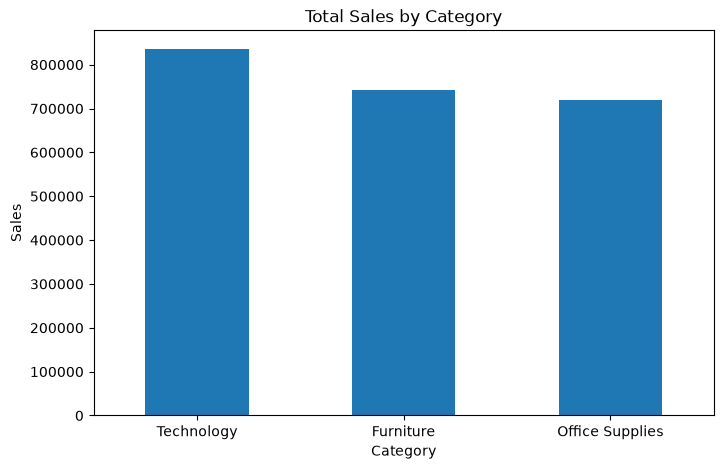

In [6]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)

plt.show()

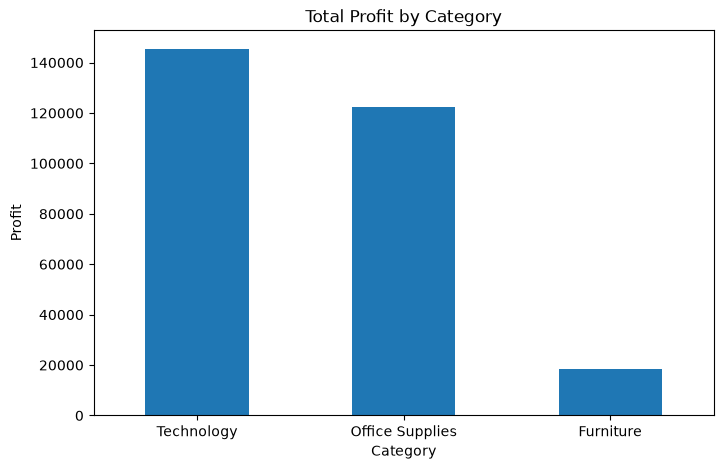

In [7]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_profit.plot(kind='bar')

plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.xticks(rotation=0)

plt.show()

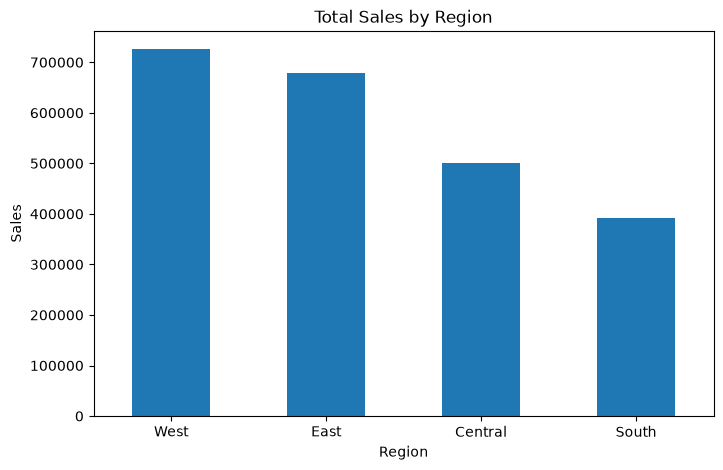

In [8]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)

plt.show()

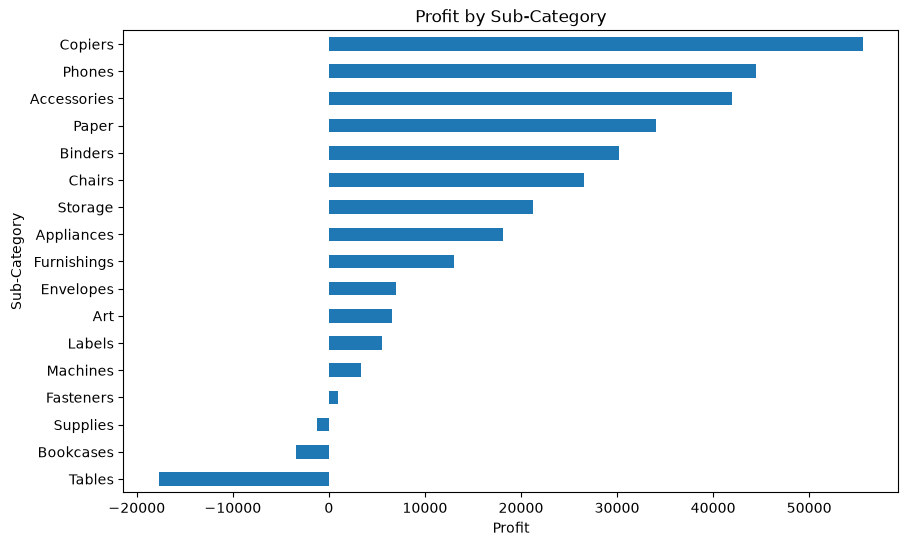

In [9]:
subcategory_profit = (
    df.groupby('Sub-Category')['Profit']
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,6))
subcategory_profit.plot(kind='barh')

plt.title('Profit by Sub-Category')
plt.xlabel('Profit')

plt.show()

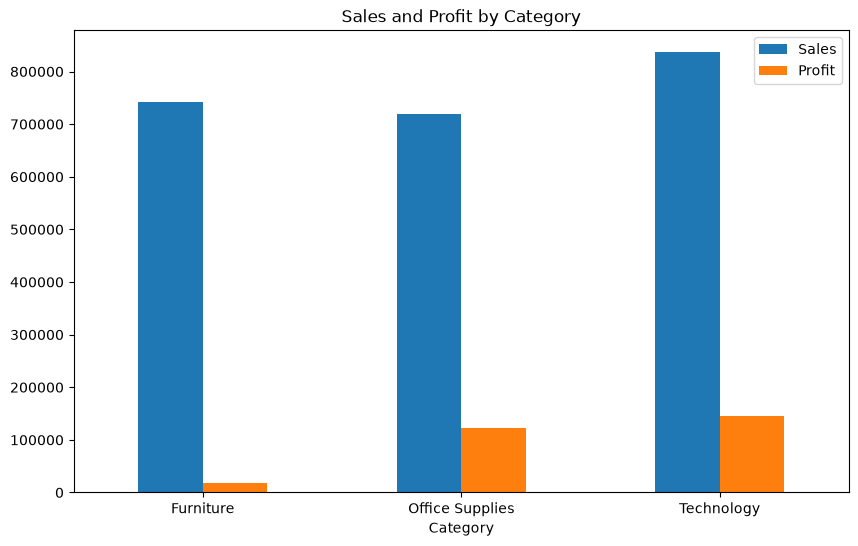

In [10]:
category_analysis = (
    df.groupby('Category')[['Sales', 'Profit']]
    .sum()
)

category_analysis.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Sales and Profit by Category')
plt.xticks(rotation=0)

plt.show()

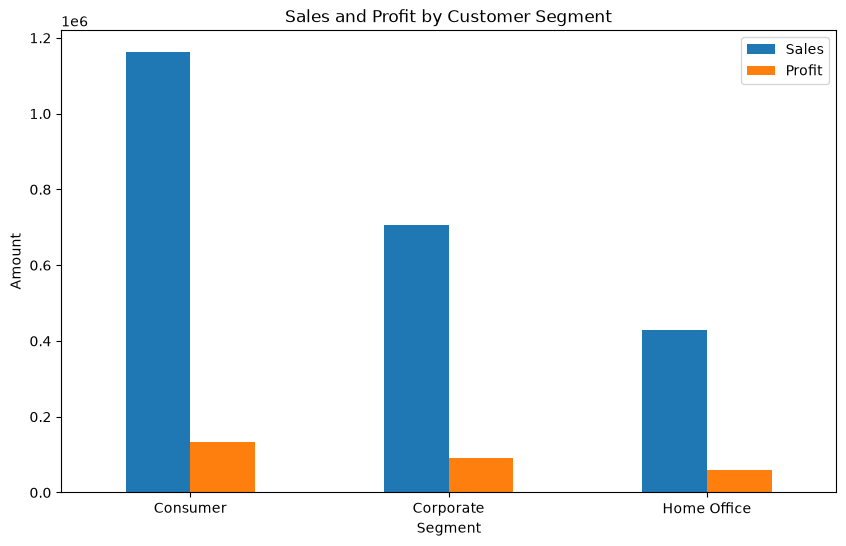

In [11]:
# Segment Analysis
segment_analysis = (
    df.groupby('Segment')[['Sales', 'Profit']]
    .sum()
)

segment_analysis.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Sales and Profit by Customer Segment')
plt.ylabel('Amount')
plt.xticks(rotation=0)

plt.show()

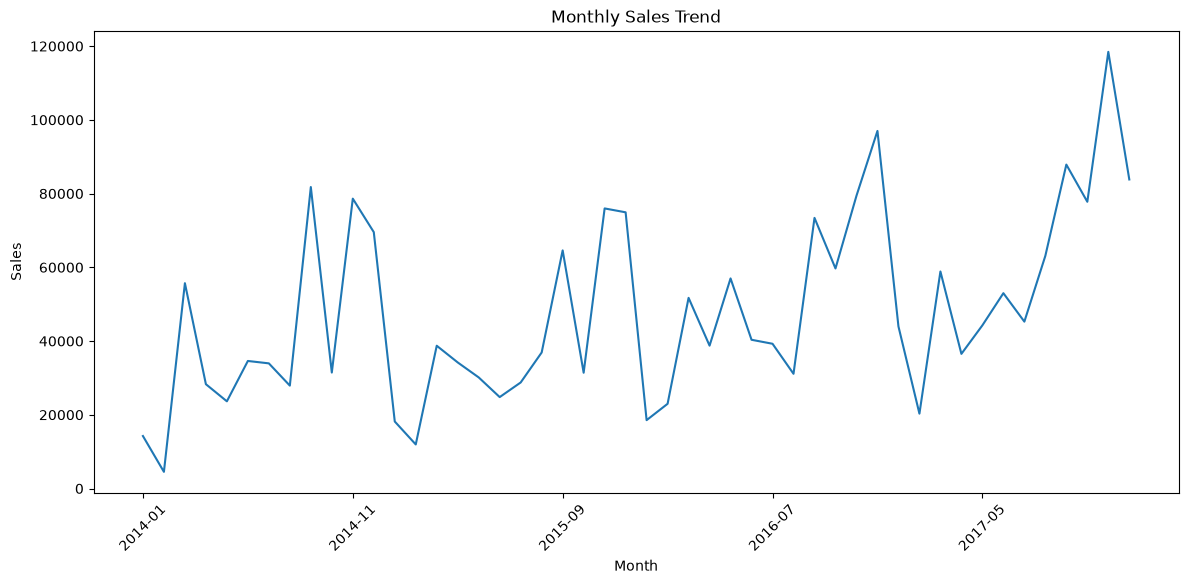

In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.show()

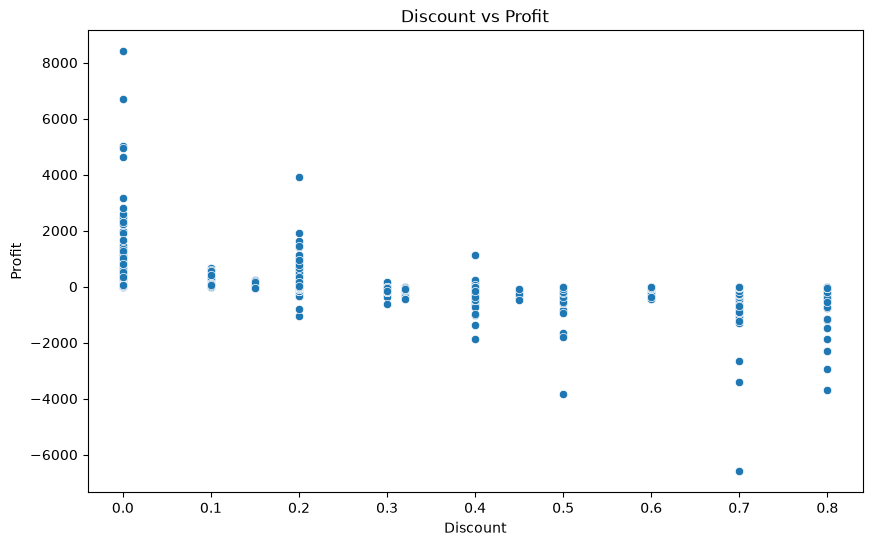

In [13]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

plt.title('Discount vs Profit')

plt.show()

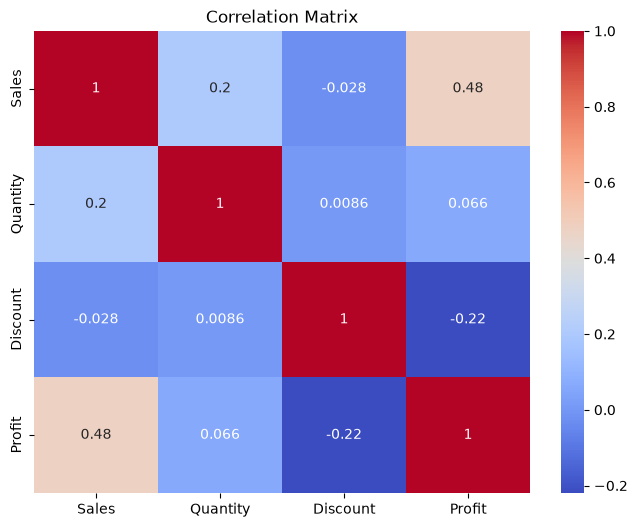

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Sales', 'Quantity', 'Discount', 'Profit']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()